In [1]:
!pip install scanpy
!pip install anndata
!pip install igraph
!pip install celltypist
!pip install decoupler

In [2]:
import scanpy as sc
import anndata as ad

In [3]:
!wget https://media.githubusercontent.com/media/josoga2/sc/refs/heads/main/bone_marrow.h5ad


--2025-11-16 15:06:42--  https://media.githubusercontent.com/media/josoga2/sc/refs/heads/main/bone_marrow.h5ad
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 354509549 (338M) [application/octet-stream]
Saving to: ‘bone_marrow.h5ad.1’

bone_marrow.h5ad.1  100%[===================>] 338.09M  6.66MB/s    in 62s     

2025-11-16 15:07:44 (5.44 MB/s) - ‘bone_marrow.h5ad.1’ saved [354509549/354509549]



AnnData object with n_obs × n_vars = 14783 × 17374
    obs: 'disease stage', 'treatment', 'timepoint', 'Dataset', 'sample', 'disease_original', 'disease_general', 'COVID-19 Condition', 'Lineage', 'Cell.group', 'Cell.class_reannotated', 'n_genes', 'n_counts', 'percent_mito', 'tissue_original', 'tissue_ontology_term_id', 'disease_ontology_term_id', 'donor_id', 'development_stage_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'n_cells', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'doi', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_pca', 'X_tsne', 'X_umap'


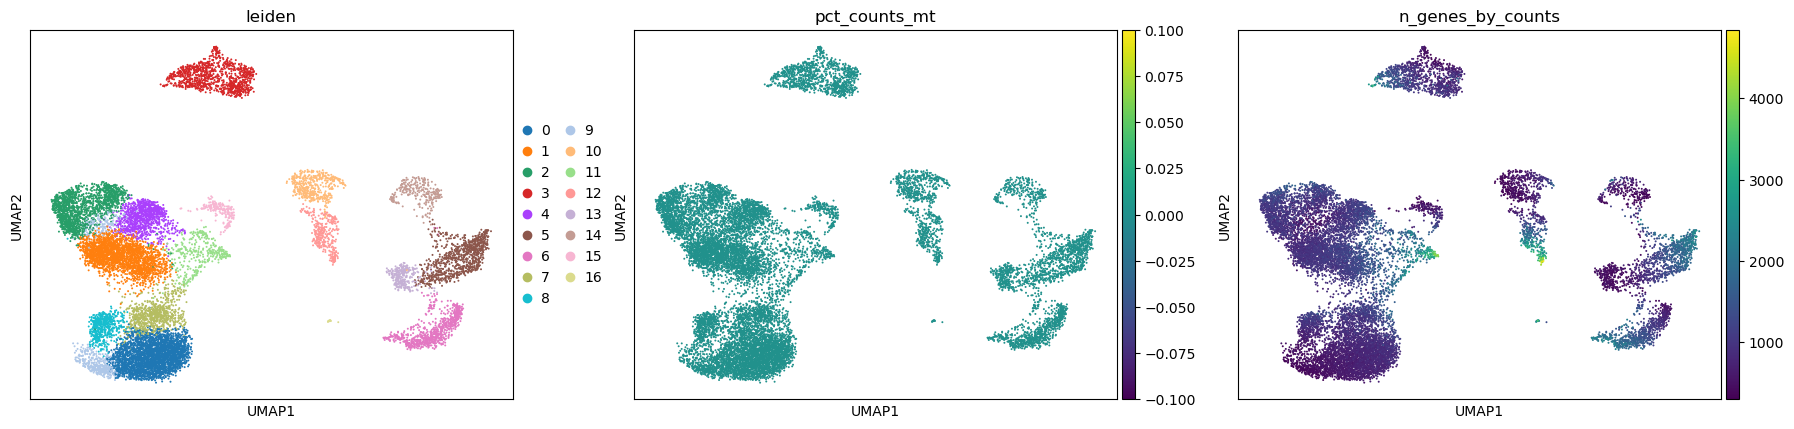

In [84]:
bone_marrow_adata= sc.read_h5ad("/Users/kashish/Downloads/bone_marrow (2).h5ad")
print (bone_marrow_adata)
import scanpy as sc
import numpy as np
from scipy.sparse import issparse

# ---------------------------
# 1. BASIC QC SETUP
# ---------------------------

# 1.1 Identify mitochondrial genes
bone_marrow_adata.var['mt'] = bone_marrow_adata.var_names.str.upper().str.startswith('MT-')

# 1.2 Compute QC metrics
sc.pp.calculate_qc_metrics(
    bone_marrow_adata, 
    qc_vars=['mt'], 
    percent_top=None, 
    log1p=False, 
    inplace=True
)

# ---------------------------
# 2. FILTER LOW-QUALITY CELLS & GENES
# ---------------------------

# 2.1 Remove cells with ZERO counts (your previous error source)
bone_marrow_adata = bone_marrow_adata[bone_marrow_adata.obs['total_counts'] > 0].copy()

# 2.2 Reasonable QC thresholds  
# (safe values; will NOT delete everything)
sc.pp.filter_cells(bone_marrow_adata, min_genes=200)    # cells with ≥200 genes
sc.pp.filter_genes(bone_marrow_adata, min_cells=3)      # genes in ≥3 cells

# Optional: filter based on mitochondrial % and count outliers
bone_marrow_adata = bone_marrow_adata[bone_marrow_adata.obs['pct_counts_mt'] < 20].copy()
bone_marrow_adata = bone_marrow_adata[bone_marrow_adata.obs['total_counts'] < 30000].copy()
bone_marrow_adata = bone_marrow_adata[bone_marrow_adata.obs['n_genes_by_counts'] < 7000].copy()

# ---------------------------
# 3. NORMALIZATION & HVG
# ---------------------------

# 3.1 Normalize counts per cell
sc.pp.normalize_total(bone_marrow_adata, target_sum=1e4)

# 3.2 Log transform
sc.pp.log1p(bone_marrow_adata)

# 3.3 Identify highly variable genes
sc.pp.highly_variable_genes(
    bone_marrow_adata,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5
)

bone_marrow_adata = bone_marrow_adata[:, bone_marrow_adata.var['highly_variable']].copy()

# ---------------------------
# 4. SCALE + PCA
# ---------------------------

sc.pp.scale(bone_marrow_adata, max_value=10)
sc.tl.pca(bone_marrow_adata, svd_solver='arpack')

# ---------------------------
# 5. NEIGHBORS + UMAP
# ---------------------------

sc.pp.neighbors(bone_marrow_adata, n_neighbors=15, n_pcs=40)
sc.tl.umap(bone_marrow_adata)

# ---------------------------
# 6. CLUSTERING
# ---------------------------

sc.tl.leiden(bone_marrow_adata, resolution=1.0)

# ---------------------------
# 7. PLOTTING
# ---------------------------

sc.pl.umap(bone_marrow_adata, color=['leiden', 'pct_counts_mt', 'n_genes_by_counts'])


In [86]:
print(bone_marrow_adata.var_names[:20])


Index(['ENSG00000122335', 'ENSG00000175548', 'ENSG00000204860',
       'ENSG00000164512', 'ENSG00000162623', 'ENSG00000134321',
       'ENSG00000166250', 'ENSG00000157388', 'ENSG00000148498',
       'ENSG00000162894', 'ENSG00000196912', 'ENSG00000185522',
       'ENSG00000170365', 'ENSG00000163131', 'ENSG00000124783',
       'ENSG00000152527', 'ENSG00000187837', 'ENSG00000181896',
       'ENSG00000121766', 'ENSG00000206562'],
      dtype='object')


In [92]:
for ct, genes in marker_genes.items():
    present = [g for g in genes if g in bone_marrow_adata.var_names]
    print(f"{ct}: {len(present)} / {len(genes)} markers found -> {present}")


HSC/Progenitor: 3 / 4 markers found -> ['CD34', 'CD38', 'GATA2']
T_cells: 3 / 4 markers found -> ['CD3D', 'CD3E', 'TRAC']
B_cells: 2 / 3 markers found -> ['MS4A1', 'CD79A']
NK_cells: 2 / 3 markers found -> ['NKG7', 'GNLY']
Monocytes: 1 / 3 markers found -> ['LYZ']
Dendritic: 0 / 3 markers found -> []
Megakaryocytes: 3 / 3 markers found -> ['PF4', 'ITGA2B', 'GP1BA']
Erythroid: 3 / 3 markers found -> ['HBB', 'HBA1', 'HBA2']
Mesenchymal: 1 / 3 markers found -> ['PDGFRA']
Endothelial: 1 / 3 markers found -> ['VWF']


In [95]:
present_markers = {ct: [g for g in genes if g in bone_marrow_adata.var_names] 
                   for ct, genes in marker_genes.items() if any(g in bone_marrow_adata.var_names for g in genes)}
print(present_markers)


{'HSC/Progenitor': ['CD34', 'CD38', 'GATA2'], 'T_cells': ['CD3D', 'CD3E', 'TRAC'], 'B_cells': ['MS4A1', 'CD79A'], 'NK_cells': ['NKG7', 'GNLY'], 'Monocytes': ['LYZ'], 'Megakaryocytes': ['PF4', 'ITGA2B', 'GP1BA'], 'Erythroid': ['HBB', 'HBA1', 'HBA2'], 'Mesenchymal': ['PDGFRA'], 'Endothelial': ['VWF']}


In [97]:
import numpy as np

# Initialize scores
for ct, genes in valid_markers.items():
    expr = bone_marrow_adata[:, genes].X
    # Compute mean expression across markers, normalize by number of markers
    bone_marrow_adata.obs[f"{ct}_score"] = expr.mean(axis=1) / len(genes)

# Assign cell type
score_cols = [f"{ct}_score" for ct in valid_markers]
bone_marrow_adata.obs['cell_type'] = bone_marrow_adata.obs[score_cols].idxmax(axis=1)
bone_marrow_adata.obs['cell_type'] = bone_marrow_adata.obs['cell_type'].str.replace("_score", "")

# Optionally, flag low-confidence cells
max_scores = bone_marrow_adata.obs[score_cols].max(axis=1)
bone_marrow_adata.obs.loc[max_scores < 0.01, 'cell_type'] = 'unknown'


In [103]:
import decoupler as dc
import scanpy as sc

# Make sure var_names are gene symbols
bone_marrow_adata.var_names = bone_marrow_adata.var['feature_name']
bone_marrow_adata.var_names_make_unique()


In [107]:
 import decoupler as dc

# Show available OmniPath resources
resources = dc.op.show_resources()
print(resources)

# Load a specific resource, for example DoRothEA
net = dc.op.dorothea(organism="human", levels=["A", "B", "C"], license="academic")

# Or, load a generic resource by name
# net = dc.op.resource(name="SIGNOR", organism="human", license="academic")


                 name     license
0            Adhesome  commercial
1           Almen2009  commercial
2          Baccin2019    academic
3        CORUM_Funcat    academic
4            CORUM_GO    academic
..                ...         ...
76              iTALK    academic
77         kinase.com  non_profit
78          scConnect  commercial
79  scConnect_complex  commercial
80             talklr  commercial

[81 rows x 2 columns]


In [113]:
dc.mt.ulm(
    data=adata,
    net=network,
   
    verbose=True,
    tmin=1  # or tmin=2
)


ulm - Running ulm
Extracted omics mat with 14780 rows (observations) and 15843 columns (features)
Network adjacency matrix has 23 unique features and 8 unique sources


  0%|          | 0/1 [00:00<?, ?it/s]

ulm - fitting 8 univariate models of 15843 observations (targets) with 15841 degrees of freedom
ulm - adjusting p-values by FDR
ulm - done


In [116]:
scores_df = pd.DataFrame(
    adata.obsm["score_ulm"],
    index=adata.obs_names,
    columns=[source for source in network["source"].unique()]
)


In [117]:
# Annotate each cell with the highest-scoring cell type
adata.obs['cell_anno'] = scores_df.idxmax(axis=1)


... storing 'cell_anno' as categorical
... storing 'symbol' as categorical


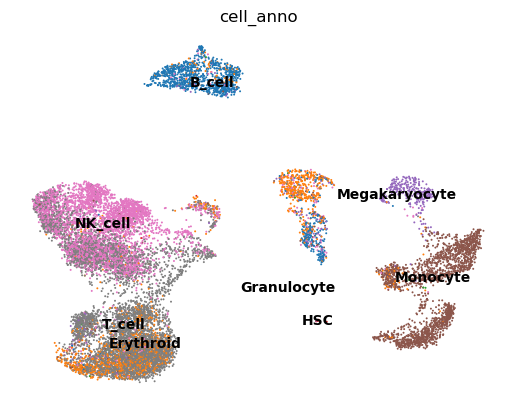

In [118]:
import scanpy as sc
sc.pl.umap(adata, color="cell_anno", legend_loc="on data", frameon=False)
